Background: Lane analyzed extracetd and found weird patterns in Flair.
![alt text](image.png)

Here, i replicate the same view.

In [1]:
##imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys

%matplotlib inline
from matplotlib import pyplot as plt
sys.path.append(os.path.join(os.getcwd(), '..','..'))

from datetime import datetime, timedelta
import importlib
from tqdm import tqdm

import studies
#from studies import DCLP3,DCLP5,ReplaceBG,Flair,Loop,PEDAP,IOBP2, T1DEXI, T1DEXIP
from studies.studydataset import StudyDataset
from studies.dataset_initializer import initialize_datasets
from src import drawing, cdf, tdd, logger, pandas_helper

import logging
logger = logger.Logger.get_logger("",logging.WARNING)

In [2]:
path = os.path.join(os.getcwd(),'..', '..', 'data', 'raw')
out_path = os.path.join(os.getcwd(),'..', '..', 'data', 'out')
studies = initialize_datasets(path)
studies

{'IOBP2': <studies.iobp2.IOBP2 at 0x105b37110>,
 'Flair': <studies.flair.Flair at 0x130cc2b90>,
 'PEDAP': <studies.pedap.PEDAP at 0x105b42d50>,
 'DCLP3': <studies.dclp.DCLP3 at 0x16c61b410>,
 'DCLP5': <studies.dclp.DCLP5 at 0x16c619cd0>,
 'ReplaceBG': <studies.replacebg.ReplaceBG at 0x16c61ae10>,
 'Loop': <studies.loop.Loop at 0x130df2950>,
 'T1DEXI': <studies.t1dexi.T1DEXI at 0x16c61ad90>,
 'T1DEXIP': <studies.t1dexi.T1DEXIP at 0x130e3a5d0>}

## Flair

In [3]:
flair = studies['Flair']
flair.extract_basal_event_history()
flair.extract_bolus_event_history();

In [5]:
#extract
df_basal = flair.extract_basal_event_history()
df_bolus = flair.extract_bolus_event_history()
    
#csv
flair.save_basal_event_history_to_file(out_path)
flair.save_bolus_event_history_to_file(out_path)
df_basal_csv = pd.read_csv(os.path.join(out_path, 'Flair_basal_event_history.csv'))
df_bolus_csv = pd.read_csv(os.path.join(out_path, 'Flair_bolus_event_history.csv'))
df_basal_csv['datetime'] = pd.to_datetime(df_basal_csv['datetime'],unit='s')
df_basal_csv['patient_id'] = df_basal_csv['patient_id'].astype('str')
df_bolus_csv['datetime'] = pd.to_datetime(df_bolus_csv['datetime'],unit='s')
df_bolus_csv['patient_id'] = df_bolus_csv['patient_id'].astype('str')
df_bolus_csv['delivery_duration'] = pd.to_timedelta(df_bolus_csv['delivery_duration'],unit='s')

#parquet
flair.save_basal_event_history_to_file(out_path,output_format='parquet')
flair.save_bolus_event_history_to_file(out_path,output_format='parquet')
df_basal_prq = pd.read_parquet(os.path.join(out_path, 'study_name=Flair/data_type=basal'))
df_bolus_prq = pd.read_parquet(os.path.join(out_path, 'study_name=Flair/data_type=bolus'))
df_basal_prq = df_basal_prq.astype({"patient_id": str})
df_bolus_prq = df_bolus_prq.astype({"patient_id": str})


print(f"Length of df_basal: {len(df_basal)}")
print(f"Length of df_bolus: {len(df_bolus)}")
print(f"Length of df_basal_csv: {len(df_basal_csv)}")
print(f"Length of df_bolus_csv: {len(df_bolus_csv)}")
print(f"Length of df_basal_prq: {len(df_basal_prq)}")
print(f"Length of df_bolus_prq: {len(df_bolus_prq)}")

Length of df_basal: 142653
Length of df_bolus: 3388050
Length of df_basal_csv: 142653
Length of df_bolus_csv: 3388050
Length of df_basal_prq: 142653
Length of df_bolus_prq: 3388050


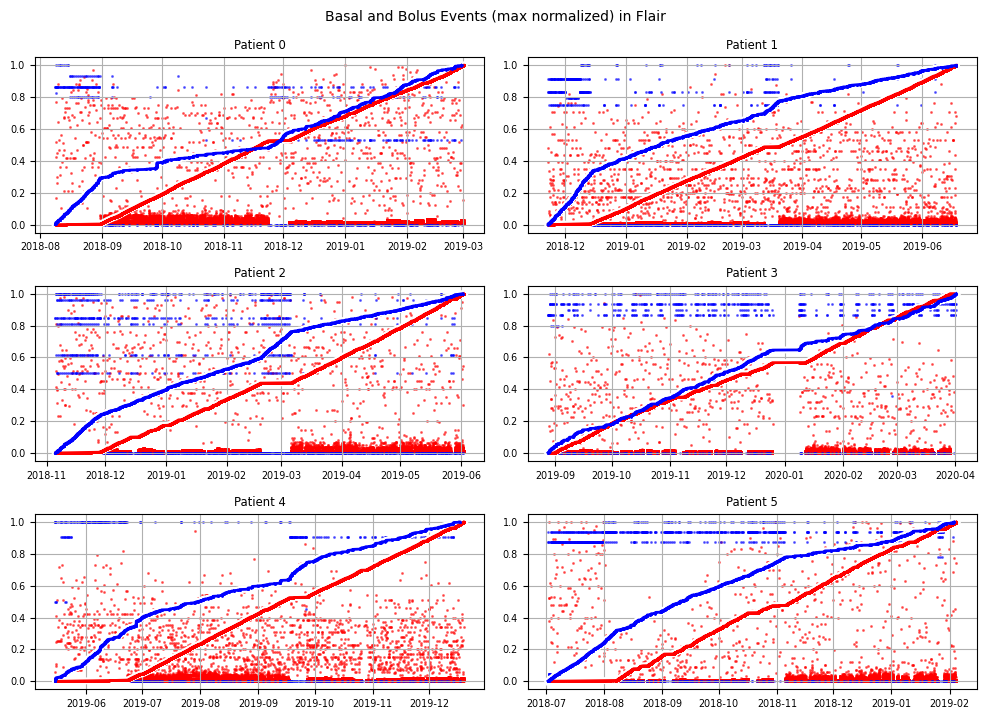

In [ ]:
patients = ['1', '2', '3', '4','5','6']
fig, axes = plt.subplots(3, 2, figsize=(10, 7), sharex=False, sharey=False)
axes = axes.flatten()

format = 'extract'
for i, patient in enumerate(patients):
    if format == 'csv':
        basals = df_basal_csv.loc[df_basal_csv.patient_id == patient]
        boluses = df_bolus_csv.loc[df_bolus_csv.patient_id == patient]
    elif format == 'parquet':
        basals = df_basal_prq.loc[df_basal_prq.patient_id == patient]
        boluses = df_bolus_prq.loc[df_bolus_prq.patient_id == patient]
    elif format=='extract':
        basals = df_basal.loc[df_basal.patient_id == patient]
        boluses = df_bolus.loc[df_bolus.patient_id == patient]
    
    ax = axes[i]
    #twinx = ax.twinx()
    ax.scatter(boluses.datetime, boluses.bolus/boluses.bolus.max(), color='red', marker='.', alpha=0.5, label='Boluses',s=5)
    ax.scatter(basals.datetime.values, basals.basal_rate.values/basals.basal_rate.max(), color='blue', alpha=0.5, marker='.', label='Basals',s=5)
    
    ax.set_title(f'Patient {patient}')
    #ax.set_ylabel('Bolus, Basal', fontsize='x-small')
    #twinx.set_ylabel('Basal Rate', fontsize='x-small')
    cdf.plot_cdf(boluses.datetime, ax=ax, color='white',linewidth=5)
    cdf.plot_cdf(basals.datetime, ax=ax, color='white',linewidth=5)
    cdf.plot_cdf(boluses.datetime, ax=ax, color=drawing.colors['Bolus'],linewidth=2)
    cdf.plot_cdf(basals.datetime, ax=ax, color=drawing.colors['Basal'],linewidth=2)
    
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize='x-small')
    ax.tick_params(axis='y', labelsize='x-small')
    ax.set_title(f'Patient {i}',fontsize='small')
    #twinx.tick_params(axis='y', labelsize='x-small')
    #ylabel font size small
    
plt.tight_layout()
plt.suptitle('Basal and Bolus Events (max normalized) in Flair', fontsize='medium', y=1.02)
plt.savefig(f'bolus_basal_flair_format={format}.png',dpi=300, bbox_inches='tight')